<a href="https://colab.research.google.com/github/mostafasameer-transportation/Structural-Dynamics_Project/blob/mostafasameer-transportation/Project_Structural_Dynamics2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

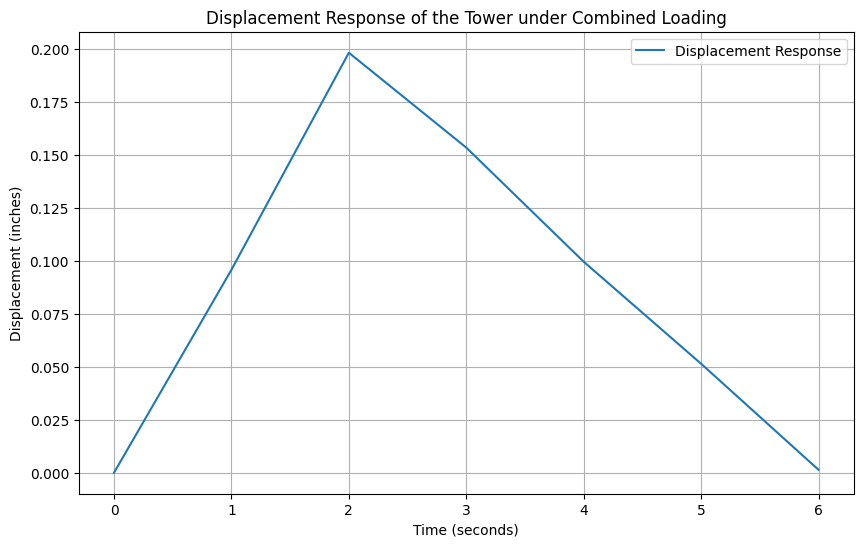

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Assuming zeta, m_eff, k_eff, total_loading, total_loading_time are defined elsewhere in your code.
# If not, define them here.
# For example:
zeta = 0.05  # Example value for damping ratio
m_eff = 10  # Example value for effective mass
k_eff = 100  # Example value for effective stiffness
total_loading = np.array([0, 10, 20, 15, 10, 5, 0])  # Example loading
total_loading_time = np.array([0, 1, 2, 3, 4, 5, 6])  # Example time


# Damping coefficient
c = 2 * zeta * np.sqrt(m_eff * k_eff)

# Define the system of equations for the damped SDOF system
def equation_of_motion(t, y):
    x, v = y  # x is displacement, v is velocity
    dxdt = v
    dvdt = (1/m_eff) * (total_loading[np.abs(total_loading_time - t).argmin()] - c*v - k_eff*x)
    return [dxdt, dvdt]

# Initial conditions: initial displacement = 0, initial velocity = 0
initial_conditions = [0, 0]

# Time span for the integration (same as the total loading time)
time_span = (total_loading_time[0], total_loading_time[-1])

# Solve the ODE
solution = solve_ivp(equation_of_motion, time_span, initial_conditions, t_eval=total_loading_time, method='RK45')

# Extract the displacement response
displacement_response = solution.y[0]

# Plotting the displacement response
plt.figure(figsize=(10, 6))
plt.plot(total_loading_time, displacement_response, label='Displacement Response')
plt.title('Displacement Response of the Tower under Combined Loading')
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (inches)')
plt.grid(True)
plt.legend()
plt.show()